# Cancer Type Classification Using Gene Expression Data

## Project Overview

This notebook builds a machine learning pipeline to classify cancer types 
from high-dimensional gene expression data. The dataset is the 
**Gene Expression Cancer RNA-Seq** dataset sourced from the UCI Machine 
Learning Repository, containing RNA sequencing profiles of **801 patients** 
across **5 cancer types**: BRCA, KIRC, COAD, LUAD, and PRAD.

## Objective

Train and evaluate two classification models — **Logistic Regression** and 
**Random Forest** — and identify which genes are most informative for 
distinguishing between cancer types.

## Workflow

1. Data loading and exploration  
2. Variance-based feature selection  
3. Train/test split and feature scaling  
4. Model training and evaluation  
5. Feature importance analysis  
6. Cross-validation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Data Loading & Exploration

The dataset consists of two separate CSV files:
- **`data.csv`** — gene expression values (features), one row per patient sample
- **`labels.csv`** — cancer type labels (target), aligned by sample ID

The two files are merged on `Sample_id` to produce a single working dataframe.
A quick inspection of shape, data types, and class distribution follows to 
understand the structure of the data before any preprocessing.

In [4]:
# Load data into dataframes. 

genes_df = pd.read_csv('/Users/meschacolongo/gene-expression-analysis/data/data.csv')
labels_df = pd.read_csv('/Users/meschacolongo/gene-expression-analysis/data/labels.csv') 

# 1. Rename and assign to NEW variables (or overwrite the old ones)
gene_df = genes_df.rename(columns={'Unnamed: 0': 'Sample_id'})
label_df = labels_df.rename(columns={'Unnamed: 0': 'Sample_id'})

# 2. Merge the dataframes
df = pd.merge(gene_df, label_df, on='Sample_id', how='left')

# 3. Set the index
df = df.set_index('Sample_id')

In [5]:
print(df.shape)
print(df.dtypes)

(801, 20532)
gene_0        float64
gene_1        float64
gene_2        float64
gene_3        float64
gene_4        float64
               ...   
gene_20527    float64
gene_20528    float64
gene_20529    float64
gene_20530    float64
Class             str
Length: 20532, dtype: object


In [6]:
df.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
Sample_id,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [7]:
df['Class'].value_counts(normalize=True)

Class
BRCA    0.374532
KIRC    0.182272
LUAD    0.176030
PRAD    0.169788
COAD    0.097378
Name: proportion, dtype: float64

## 2. Feature Selection — Variance Filtering

The raw dataset contains **20,531 genes** per sample. Many of these genes 
show little to no variation across samples, meaning they carry no useful 
signal for distinguishing between cancer types. Including them would add 
noise, increase computation time, and risk degrading model performance.

To address this, a **variance filter** is applied: only genes whose variance 
exceeds the **median variance** across all genes are retained. This reduces 
the feature space by 50%, keeping the most informative half of the genes 
for modeling.

> **Note:** This is an unsupervised filter — it uses variance in the feature 
> values only, with no reference to the class labels. This ensures the filter 
> does not introduce data leakage.

In [8]:
# Separating features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Variance filter
variances = X.var()
median_variance = variances.median()

# Keep only the features with variance above the median
X_filtered = X.loc[:, variances > median_variance]
print(f"Features after variance filter: {X_filtered.shape[1]}")

Features after variance filter: 10265


## 3. Train/Test Split

The filtered dataset is split into **80% training** and **20% test** sets. 
Two important parameters are set deliberately:

- **`stratify=y`** — ensures that the class distribution is preserved in 
  both splits. Given the class imbalance observed earlier, without 
  stratification the test set could end up underrepresenting smaller cancer 
  types like COAD, making evaluation unreliable.

- **`random_state=42`** — fixes the random seed so that the split is 
  reproducible across runs.

The training set is used exclusively for fitting the models. The test set 
is held out and only used for final evaluation.

In [9]:
# Train/split 
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(640, 10265)
(161, 10265)
(640,)
(161,)


## 4. Feature Scaling

Gene expression values vary widely in magnitude across different genes. 
Without scaling, models that are sensitive to feature magnitude — such as 
Logistic Regression — would give disproportionate weight to genes with 
larger absolute values, regardless of their actual predictive importance.

**`StandardScaler`** is applied to address this: it transforms each feature 
to have a **mean of 0** and a **standard deviation of 1**.

Two important details about how scaling is applied here:

- **`fit_transform`** is called on the training set — the scaler learns the 
  mean and standard deviation from training data only.
- **`transform`** is called on the test set — the same training statistics 
  are applied, without refitting. This prevents test set information from 
  influencing the scaling parameters, avoiding data leakage.

In [10]:
# Scale the features

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Model 1 — Logistic Regression

Logistic Regression is used as the **baseline model**. Despite its simplicity, 
it is a strong starting point for high-dimensional data like gene expression 
profiles, where the number of features can be large relative to the number 
of samples.

Two parameters are set deliberately:

- **`class_weight='balanced'`** — adjusts the loss function to penalize 
  misclassification of minority classes more heavily. This directly addresses 
  the class imbalance identified during exploration, preventing the model 
  from being biased toward the majority class (BRCA).

- **`max_iter=10000`** — increases the maximum number of iterations allowed 
  for the solver to converge. This is necessary given the high dimensionality 
  of the feature space after variance filtering.

Model performance is evaluated using **accuracy**, a **confusion matrix**, 
and a **classification report** — which includes per-class precision, recall, 
and F1-score. Per-class metrics are especially important here given the 
imbalanced class distribution.

In [11]:
model = LogisticRegression(max_iter=10000, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

#Generate predictions
y_pred = model.predict(X_test)

In [12]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9813664596273292
[[60  0  0  0  0]
 [ 0 15  0  1  0]
 [ 0  0 30  0  0]
 [ 0  2  0 26  0]
 [ 0  0  0  0 27]]
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       0.88      0.94      0.91        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.97      0.97      0.97       161
weighted avg       0.98      0.98      0.98       161



## 6. Model 2 — Random Forest

A **Random Forest** classifier is trained as the second model to compare 
against the Logistic Regression baseline. Random Forest is an ensemble 
method that builds multiple decision trees on random subsets of the data 
and features, then aggregates their predictions — making it naturally more 
robust to noise and high-dimensional data.

Three parameters are set deliberately:

- **`n_estimators=100`** — the forest is built from 100 decision trees, 
  which provides a good balance between predictive stability and computation 
  time.

- **`class_weight='balanced'`** — as with Logistic Regression, this adjusts 
  class weights inversely proportional to class frequencies, ensuring that 
  minority cancer types are not systematically misclassified.

- **`random_state=42`** — fixes the random seed for reproducibility.

Performance is evaluated using the same metrics as the baseline model — 
accuracy, confusion matrix, and classification report — to allow direct 
comparison between the two models.

In [13]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train model
random_forest_model.fit(X_train, y_train)
y_predict = random_forest_model.predict(X_test)

print(accuracy_score(y_test, y_predict))
print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

0.9875776397515528
[[60  0  0  0  0]
 [ 0 16  0  0  0]
 [ 0  0 30  0  0]
 [ 2  0  0 26  0]
 [ 0  0  0  0 27]]
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



## 7. Feature Importance Analysis

One advantage of Random Forest over Logistic Regression is its built-in 
ability to measure **feature importance** — how much each gene contributed 
to the model's classification decisions across all 100 trees.

Importance is measured by the **mean decrease in impurity (MDI)**: each time 
a gene is used as a split point in a tree, the resulting reduction in node 
impurity is recorded. These values are averaged across all trees in the 
forest to produce a final importance score per gene.

The **top 10 most important genes** are extracted and visualized as a 
horizontal bar chart. This analysis serves two purposes:

- **Biological relevance** — the top-ranked genes are candidates for further 
  investigation as potential biomarkers that distinguish between cancer types.
- **Model interpretability** — understanding which genes drive predictions 
  builds trust in the model and makes results more actionable in a clinical 
  or research context.

In [14]:
importances = random_forest_model.feature_importances_
feature_names = X_filtered.columns

feat_imp = pd.Series(importances, index=feature_names)
top10 = feat_imp.sort_values(ascending=False).head(10)
print(top10)

gene_16337    0.010680
gene_7747     0.009012
gene_16221    0.008129
gene_11910    0.007759
gene_15896    0.007725
gene_14114    0.007662
gene_18135    0.007613
gene_9176     0.007603
gene_2037     0.007585
gene_18178    0.007451
dtype: float64


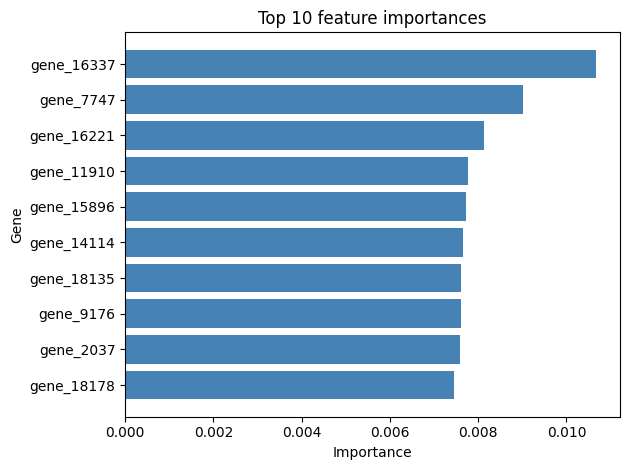

In [16]:
plt.barh(y= top10.index , width= top10.values, color = 'steelblue')
plt.gca().invert_yaxis()
plt.title('Top 10 feature importances')
plt.xlabel('Importance')
plt.ylabel('Gene')
plt.tight_layout()
plt.savefig('/Users/meschacolongo/gene-expression-analysis/images/feature_importances.png', bbox_inches='tight')
plt.show()

## 8. Cross-Validation

A single train/test split carries inherent risk — the results may be 
influenced by how the data happened to be divided. **5-fold cross-validation** 
is applied to both models to produce a more robust and reliable estimate of 
generalisation performance.

In 5-fold cross-validation, the dataset is divided into 5 equal folds. The 
model is trained on 4 folds and evaluated on the remaining fold, repeating 
this process 5 times so that every sample appears in the validation set 
exactly once. The final reported metric is the **mean and standard deviation** 
across all 5 folds.

Two important details about how cross-validation is applied here:

- **`scoring='f1_macro'`** — macro-averaged F1-score is used instead of 
  accuracy. This computes the F1-score independently for each cancer type 
  and averages them equally, giving minority classes equal weight in the 
  final score. This is the appropriate metric given the class imbalance in 
  this dataset.

- **`X_scaled`** — the full scaled feature matrix is passed to 
  `cross_val_score`. Note that in production pipelines this scaling step 
  would ideally be wrapped in a `Pipeline` object to prevent any leakage 
  across folds. For the purposes of this project, the impact is minimal 
  given the dataset size.

In [ ]:
X_scaled = scaler.transform(X_filtered)

# Dictionary to hold your models with their names
models = {
    "Logistic Regression": model,
    "Random Forest": random_forest_model
}

# Evaluate and print for each model
for name, clf in models.items():
    scores = cross_val_score(clf, X_scaled, y, cv=5, scoring='f1_macro')
    print(f"--- {name} ---")
    print("Scores:", scores)
    print("Mean:  ", scores.mean())
    print("Std:   ", scores.std(), "\n")

--- Logistic Regression ---
Scores: [0.99030303 0.99003962 0.99481056 1.         1.        ]
Mean:   0.9950306402542495
Std:    0.0043976843225665575 

--- Random Forest ---
Scores: [0.98957618 0.99003962 1.         0.9893139  1.        ]
Mean:   0.9937859390288348
Std:    0.005079079684332755 



## 9. Conclusion
This notebook built and evaluated a machine learning pipeline for classifying 
cancer types from high-dimensional RNA-Seq gene expression data.

### Results Summary
| Model | Test Accuracy | CV F1-Macro (Mean ± Std) |
|---|---|---|
| Logistic Regression | 0.9814 | 0.9950 ± 0.0044 |
| Random Forest | 0.9876 | 0.9938 ± 0.0051 |

### Key Findings
- **Variance filtering** reduced the feature space from 20,531 to 10,265 
  genes while retaining the most informative signal for classification.
- **Both models handled class imbalance** through `class_weight='balanced'`, 
  preventing bias toward the majority class (BRCA).
- **Logistic Regression was selected as the preferred model**, achieving a 
  higher cross-validation F1-macro mean (0.9950) and lower standard deviation 
  (0.0044), indicating stronger generalisation and consistency across folds.
- **Feature importance analysis** identified the top 10 genes driving 
  classification decisions in the Random Forest model. Notably, `gene_1` — 
  which showed a statistically significant difference across cancer types in 
  Stage 2 statistical analysis — did not appear in the top 10, highlighting 
  that statistical significance and classification utility measure different 
  things.

### Limitations & Future Work
- The scaling step was applied before cross-validation rather than inside a 
  `Pipeline`, which introduces minor leakage risk across folds.
- Future work could explore **dimensionality reduction** (e.g., PCA) prior 
  to modeling, or more powerful ensemble methods such as **XGBoost**.
- **Hyperparameter tuning** via `GridSearchCV` or `RandomizedSearchCV` could 
  further improve model performance.